# Hypothesis Testing

Hypothesis testing is a critical tool in knowing what the value of a parameter could be.

The basis of our testing has two attributes:

**Null Hypothesis: $H_0$**

**Alternative Hypothesis: $H_a$**

The tests we will discuss are:

* One Population Proportion
* Difference in Population Proportions
* One Population Mean
* Difference in Population Means

In this tutorial, I will introduce some functions that are extremely useful when calculating a t-statistic and p-value for a hypothesis test.

Let's quickly review the following ways to calculate a test statistic for the tests listed above.

The equation is:

$$\frac{Best\ Estimate - Hypothesized\ Estimate}{Standard\ Error\ of\ Estimate}$$

We will use the examples from our lectures and use python functions to streamline our tests.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats.distributions as dist
from scipy.stats import ttest_1samp
import seaborn as sns

In [2]:
tips_df = sns.load_dataset('tips')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Population Proportion

In [3]:
counts = tips_df['smoker'].value_counts()
percs = tips_df['smoker'].value_counts(normalize=True)
smokers = pd.concat([counts,percs], axis=1, keys=['count', 'percentage'])
smokers

,count,percentage
smoker,,
No,151,0.618852
Yes,93,0.381148


Question: do more restaurant visitors choose smoking tables?

population = adults (18+) of restaurant visitors.

param of interest = proportion of smokers

We are testing to see if there is a statistically significant increase in the number of restaurant visitors
who are choosing smoking tables.

Assume alpha = 0.05.

H0: p = 0.30

Ha: p > 0.30

Check assumptions:
- sample was random sample.
- sample size is large enough, and we cover both smokers and non-smokers in our data.

In this case the standard error is:

$$S.E. = \sqrt{\frac{P_0 * (1 - P_0)}{n}}$$

In [4]:
n = 244
p0 = 0.3
p_hat = 0.38
alpha = 0.05

se = np.sqrt((p0 * (1 - p0)) / n)
print("SE = ", se)
z_stat = (p_hat - p0) / se
print("Z test statistic = ", z_stat)

SE =  0.02933693470192341
Z test statistic =  2.72693793038831


Our observed sample proportion is 2.73 null standard errors above the hypothesised population proportion.

We calculate the p-value from the Z distribution and conclude if it was significant or not. if p-value < alpha,
reject the null hypothesis. Otherwise, we fail to reject the null hypothesis.

Here p-value is 0.003167.

In [5]:
z, pval = sm.stats.proportions_ztest(93, 244, p0, alternative='larger')
print(f"z score: {z}", f"p-value: {pval}", sep='\n')

z score: 2.6099377888555533
p-value: 0.004527934483546115


## Difference in Population Proportions

In [6]:
smoker_by_gender = pd.crosstab(tips_df['sex'], tips_df['smoker'])
smoker_by_gender['total'] = smoker_by_gender.sum(axis=1)
smoker_by_gender['p_yes'] = smoker_by_gender['Yes'] / smoker_by_gender['total']
smoker_by_gender

smoker,Yes,No,total,p_yes
sex,,,,
Male,60,97,157,0.382166
Female,33,54,87,0.379310



Is there a significant difference between the population proportions of smokers between males and females?

**Populations**: All male and females visitors to the restaurant  
**Parameter of Interest**: p1 - p2, where p1 = male smokers and p2 = female smokers  
**Null Hypothesis:** p1 - p2 = 0  
**Alternative Hypthosis:** p1 - p2 $\neq$ 0  


60 out of 157 (38.2%) sampled males are smokers.
33 out of 87 (37.9%) sampled females are smokers.

Check assumption:
* two independent random samples
* large enough samples

Here S.E. is:

$$S.E. = \sqrt{\hat{p}(1-\hat{p})(\frac{1}{n_1}+\frac{1}{n_2})}$$

In [7]:
# Sample sizes
n1 = 157
n2 = 87

# Number of parents reporting that their child had some swimming lessons
y1 = 60
y2 = 33

# Estimates of the population proportions
p1 = y1 / n1
p2 = y2 / n2

# Estimate of the combined population proportion
phat = (y1 + y2) / (n1 + n2)

# Estimate of the variance of the combined population proportion
va = phat * (1 - phat)

# Estimate of the standard error of the combined population proportion
se = np.sqrt(va * (1 / n1 + 1 / n2))

# Test statistic and its p-value
test_stat = ((p1 - p2) - 0) / se
pvalue = 2*dist.norm.cdf(-np.abs(test_stat))

# Print the test statistic its p-value
print("Test Statistic")
print(test_stat)

print("\nP-Value")
print(pvalue)

Test Statistic
0.043986572230939734

P-Value
0.9649151073157315


The observed difference in sample proportions is 0.04 estimated standard errors above our hypothesised mean of
equal population proportions.

We calculate the p-value from the Z distribution and conclude if it was significant or not. if p-value < alpha,
reject the null hypothesis. Otherwise, we fail to reject the null hypothesis.

In [9]:
z, pval = sm.stats.proportions_ztest([y1, y2], [n1, n2], 0, alternative='two-sided')
print(f"z score: {z}", f"p-value: {pval}", sep='\n')

z score: 0.043986572230939734
p-value: 0.9649151073157315


## Population Mean

In [10]:
n = len(tips_df['total_bill'])
mean = tips_df['total_bill'].mean()
std = tips_df['total_bill'].std()

(n, mean, std)

(244, np.float64(19.78594262295082), np.float64(8.902411954856856))

Is the average bill greater than 15.0 for all visitors of the restaurant?

H0: m = 15

Ha: m > 15

To do so, we perform a one sample test.

Check the assumptions:
* Random sample
* Normal distribution (using: histogram, Q-Q plot, or hypothesis tests)

Assume the dist is normal and alpha is 0.05.

Here S.E. is:

$$S.E. = \frac{SD}{\sqrt{n}}$$

C:\Users\DELL\AppData\Local\Temp\ipykernel_18192\3759225478.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips_df['total_bill'])


<Axes: xlabel='total_bill', ylabel='Density'>

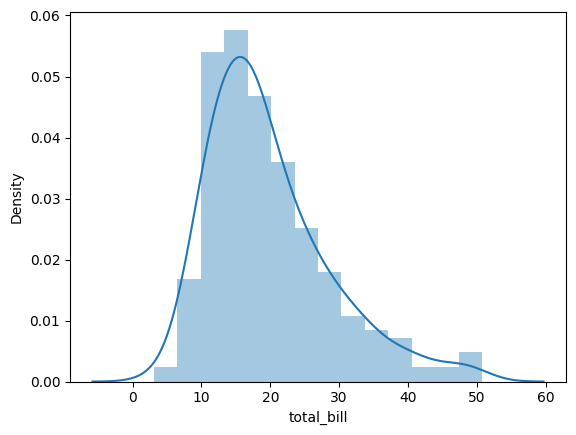

In [11]:
sns.distplot(tips_df['total_bill'])

In [12]:
se = std / np.sqrt(n)
t_statistic = (mean - 15) / se

print(t_statistic)

8.39759090218613


Our sample mean is 8.4 estimated standard errors above the null value of 15.

We calculate the p-value from the t-distribution and conclude if it was significant or not. if p-value < alpha,
reject the null hypothesis. Otherwise, we fail to reject the null hypothesis.

Here p-value is almost zero.

In [13]:
t_stat, pval = ttest_1samp(tips_df['total_bill'], 15, alternative='greater')
print(t_stat, pval, sep='\n')

8.39759090218613
1.908718407987848e-15


## Difference in Population Means

In [14]:
bill_by_gender = tips_df[['total_bill', 'sex']].groupby('sex').agg([np.mean, np.std, np.size])
bill_by_gender.columns = ['mean', 'std', 'size']
bill_by_gender

C:\Users\DELL\AppData\Local\Temp\ipykernel_18192\2281975864.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bill_by_gender = tips_df[['total_bill', 'sex']].groupby('sex').agg([np.mean, np.std, np.size])
C:\Users\DELL\AppData\Local\Temp\ipykernel_18192\2281975864.py:1: FutureWarning: The provided callable <function mean at 0x00000228FEC65C60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  bill_by_gender = tips_df[['total_bill', 'sex']].groupby('sex').agg([np.mean, np.std, np.size])
C:\Users\DELL\AppData\Local\Temp\ipykernel_18192\2281975864.py:1: FutureWarning: The provided callable <function std at 0x00000228FEC65DA0> is currently using SeriesGroupBy.std. In a future v

,mean,std,size
sex,,,
Male,20.744076,9.246469,157
Female,18.056897,8.009209,87


Is there a statistically significant difference between males and females with regards to average bill

H0: m1 - m2 = 0

Ha: m1 - m2 $\neq$ 0

To know, we perform a two sample t-test

Assumptions:
* random samples
* normal distribution
* independent samples

alpha = 0.05

Check if pooled or unpooled approach.

<Axes: xlabel='sex', ylabel='total_bill'>

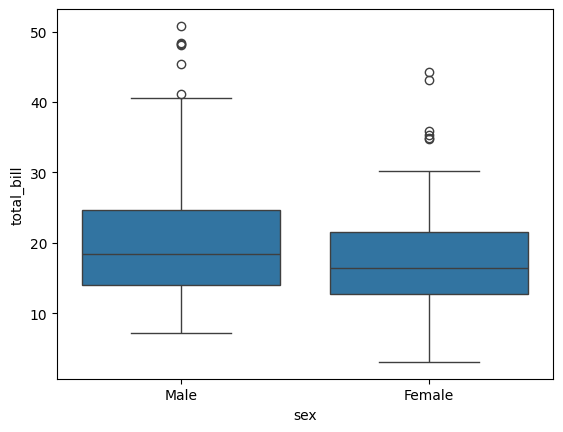

In [16]:
sns.boxplot(data=tips_df, x='sex', y='total_bill')

In [17]:
male_bills = tips_df[tips_df['sex']=='Male']['total_bill']
female_bills = tips_df[tips_df['sex']=='Female']['total_bill']

t_stat, p_val, _ = sm.stats.ttest_ind(
    male_bills, female_bills,
    alternative='two-sided',
    usevar='pooled',
    value=0
)

(t_stat, p_val)

(np.float64(2.2777940289803196), np.float64(0.02361166684685902))

Our difference in sample means is 2.27 estimated standard errors above the null difference of 0.

We calculate the p-value from the t-distribution and conclude if it was significant or not. if p-value < alpha,
reject the null hypothesis. Otherwise, we fail to reject the null hypothesis.

# Regression Analysis
how does adding the 'tip' variable affect the significance of the gender on total bill? How does this affect the results obtained previously? Try removing tip from the regression equation and see the difference.

In [23]:
model = sm.regression.linear_model.OLS.from_formula('total_bill ~ sex + tip', data=tips_df)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             total_bill   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     104.3
Date:                Sun, 31 Aug 2025   Prob (F-statistic):           2.38e-33
Time:                        23:57:42   Log-Likelihood:                -803.13
No. Observations:                 244   AIC:                             1612.
Df Residuals:                     241   BIC:                             1623.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         7.4623      1.077      6.932      0.000       5.342       9.583
sex[T.Female]    -1.5860      0.878     -1.806      0.072      -3.316       0.144
tip               4.2988      0.305     14.110      0.000       3.699       4.899
==============================================================================
Omnibus:                       58.442   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              122.742
Skew:                           1.166   Prob(JB):                     2.22e-27
Kurtosis:                       5.576   Cond. No.                         9.76
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='tip', ylabel='total_bill'>

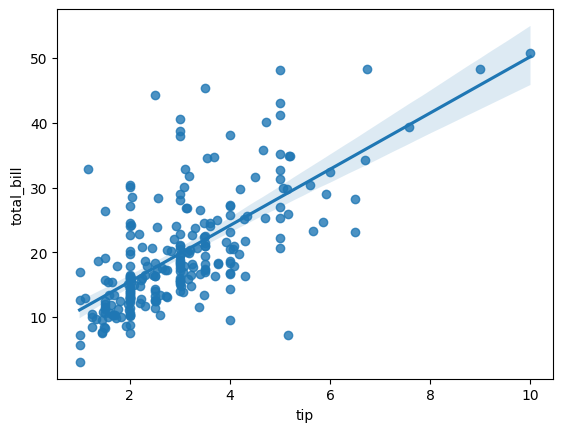

In [24]:
sns.regplot(data=tips_df, x='tip', y='total_bill')